In [ ]:
!nvidia-smi

In [ ]:
!git clone https://github.com/ultralytics/yolov5.git

In [ ]:
%pwd

In [ ]:
%cd yolov5

In [ ]:
!pip install -qr requirements.txt
import torch


from IPython.display import Image, clear_output  # to display images

print(torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU')

In [ ]:
%pwd

In [ ]:
%cd /content

In [ ]:
!unzip Helmet.v29i.yolov5pytorch.zip

In [ ]:
from ast import Num
import yaml

with open('data.yaml','r') as stream:
  Num_classes = str(yaml.safe_load(stream)['nc'])


In [ ]:
Num_classes

In [ ]:
%cat /content/yolov5/models/yolov5s.yaml

In [ ]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def writetemplate(line, cell):
  with open(line, 'w') as f:
    f.write(cell.format(**globals()))

In [ ]:
%%writetemplate /content/yolov5/models/custom_yolov5s.yaml

nc: {Num_classes} # number of classes
depth_multiple: 0.33 # model depth multiple
width_multiple: 0.50 # layer channel multiple


anchors:
  - [10, 13, 16, 30, 33, 23] # P3/8 small-object anchors
  - [30, 61, 62, 45, 59, 119] # P4/16 medium-object anchors
  - [116, 90, 156, 198, 373, 326] # P5/32 large-object anchors

# YOLOv5 v6.0 backbone
backbone:
  # [from, number, module, args]
  [
    [-1, 1, Conv, [64, 6, 2, 2]], # 0-P1/2
    [-1, 1, Conv, [128, 3, 2]], # 1-P2/4
    [-1, 3, C3, [128]],
    [-1, 1, Conv, [256, 3, 2]], # 3-P3/8
    [-1, 6, C3, [256]],
    [-1, 1, Conv, [512, 3, 2]], # 5-P4/16
    [-1, 9, C3, [512]],
    [-1, 1, Conv, [1024, 3, 2]], # 7-P5/32
    [-1, 3, C3, [1024]],
    [-1, 1, SPPF, [1024, 5]], # 9
  ]

# YOLOv5 v6.0 head
head: [
    [-1, 1, Conv, [512, 1, 1]],
    [-1, 1, nn.Upsample, [None, 2, "nearest"]],
    [[-1, 6], 1, Concat, [1]], # cat backbone P4
    [-1, 3, C3, [512, False]], # 13

    [-1, 1, Conv, [256, 1, 1]],
    [-1, 1, nn.Upsample, [None, 2, "nearest"]],
    [[-1, 4], 1, Concat, [1]], # cat backbone P3
    [-1, 3, C3, [256, False]], # 17 (P3/8-small)

    [-1, 1, Conv, [256, 3, 2]],
    [[-1, 14], 1, Concat, [1]], # cat head P4
    [-1, 3, C3, [512, False]], # 20 (P4/16-medium)

    [-1, 1, Conv, [512, 3, 2]],
    [[-1, 10], 1, Concat, [1]], # cat head P5
    [-1, 3, C3, [1024, False]], # 23 (P5/32-large)

    [[17, 20, 23], 1, Detect, [nc, anchors]], # Detect(P3, P4, P5)
  ]

In [ ]:
%cat /content/yolov5/models/custom_yolov5s.yaml

In [ ]:
%%time
%cd /content/yolov5/
!python train.py --img 416 --batch 16 --epoch 20 --data '../data.yaml' --cfg ./models/custom_yolov5s.yaml --weights 'yolov5s.pt' --name yolov5s_results --cache

/content/yolov5
WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 3
wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=./models/custom_yolov5s.yaml, data=../data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=20, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=yolov5s_results, exist_ok=False, quad=False, cos_lr

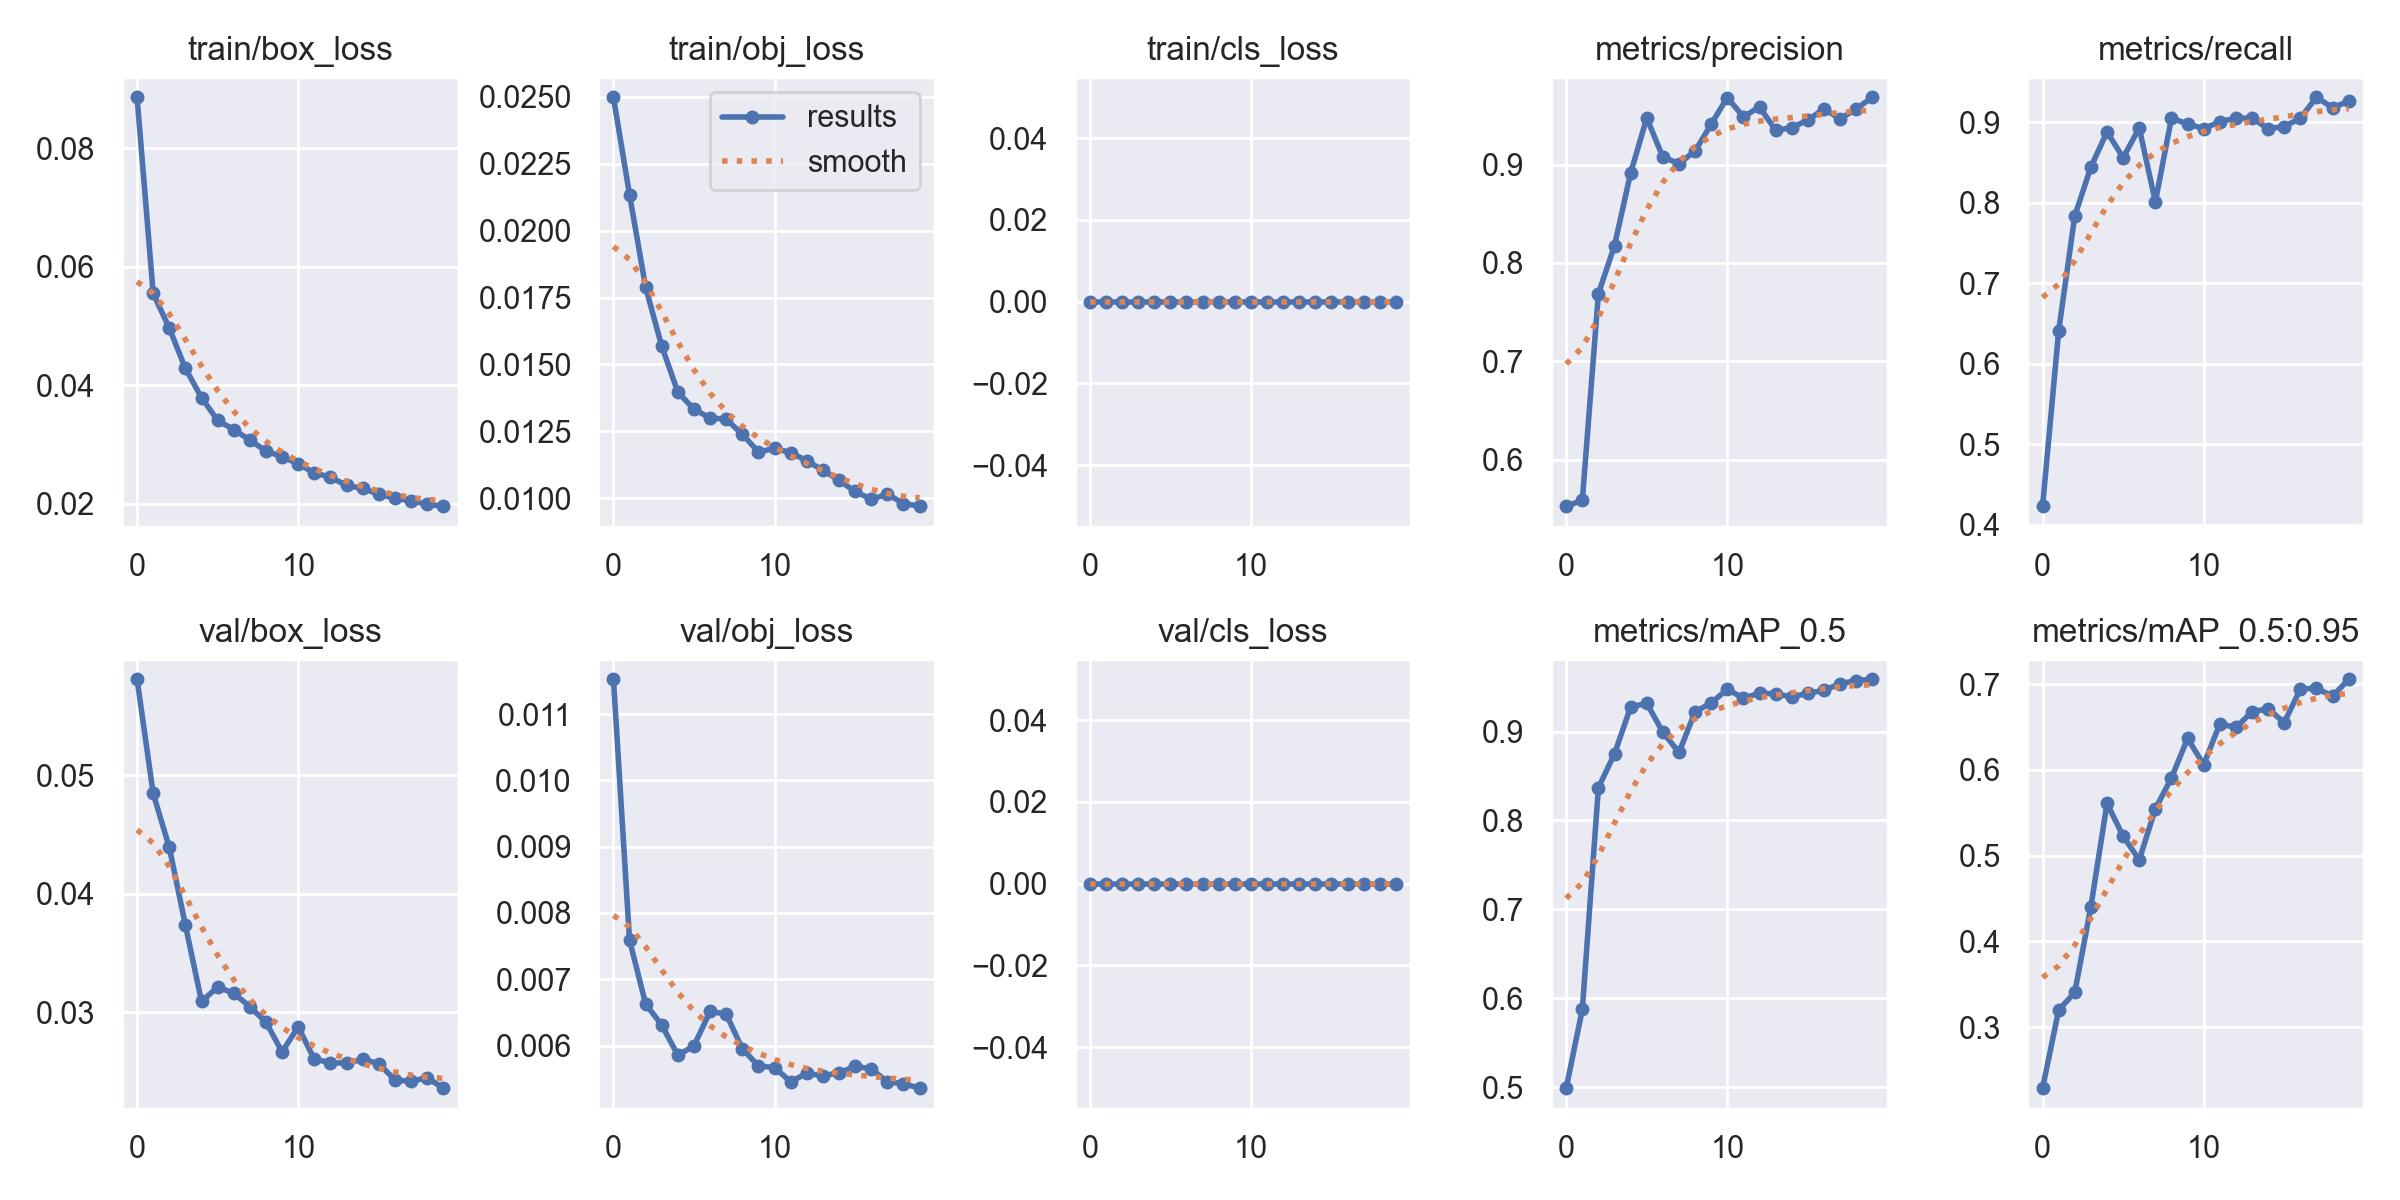

In [ ]:
from utils.plots import plot_results
Image(filename='/content/yolov5/runs/train/yolov5s_results/results.png',width=1000)

GROUND TRUTH TRAINING DATA:


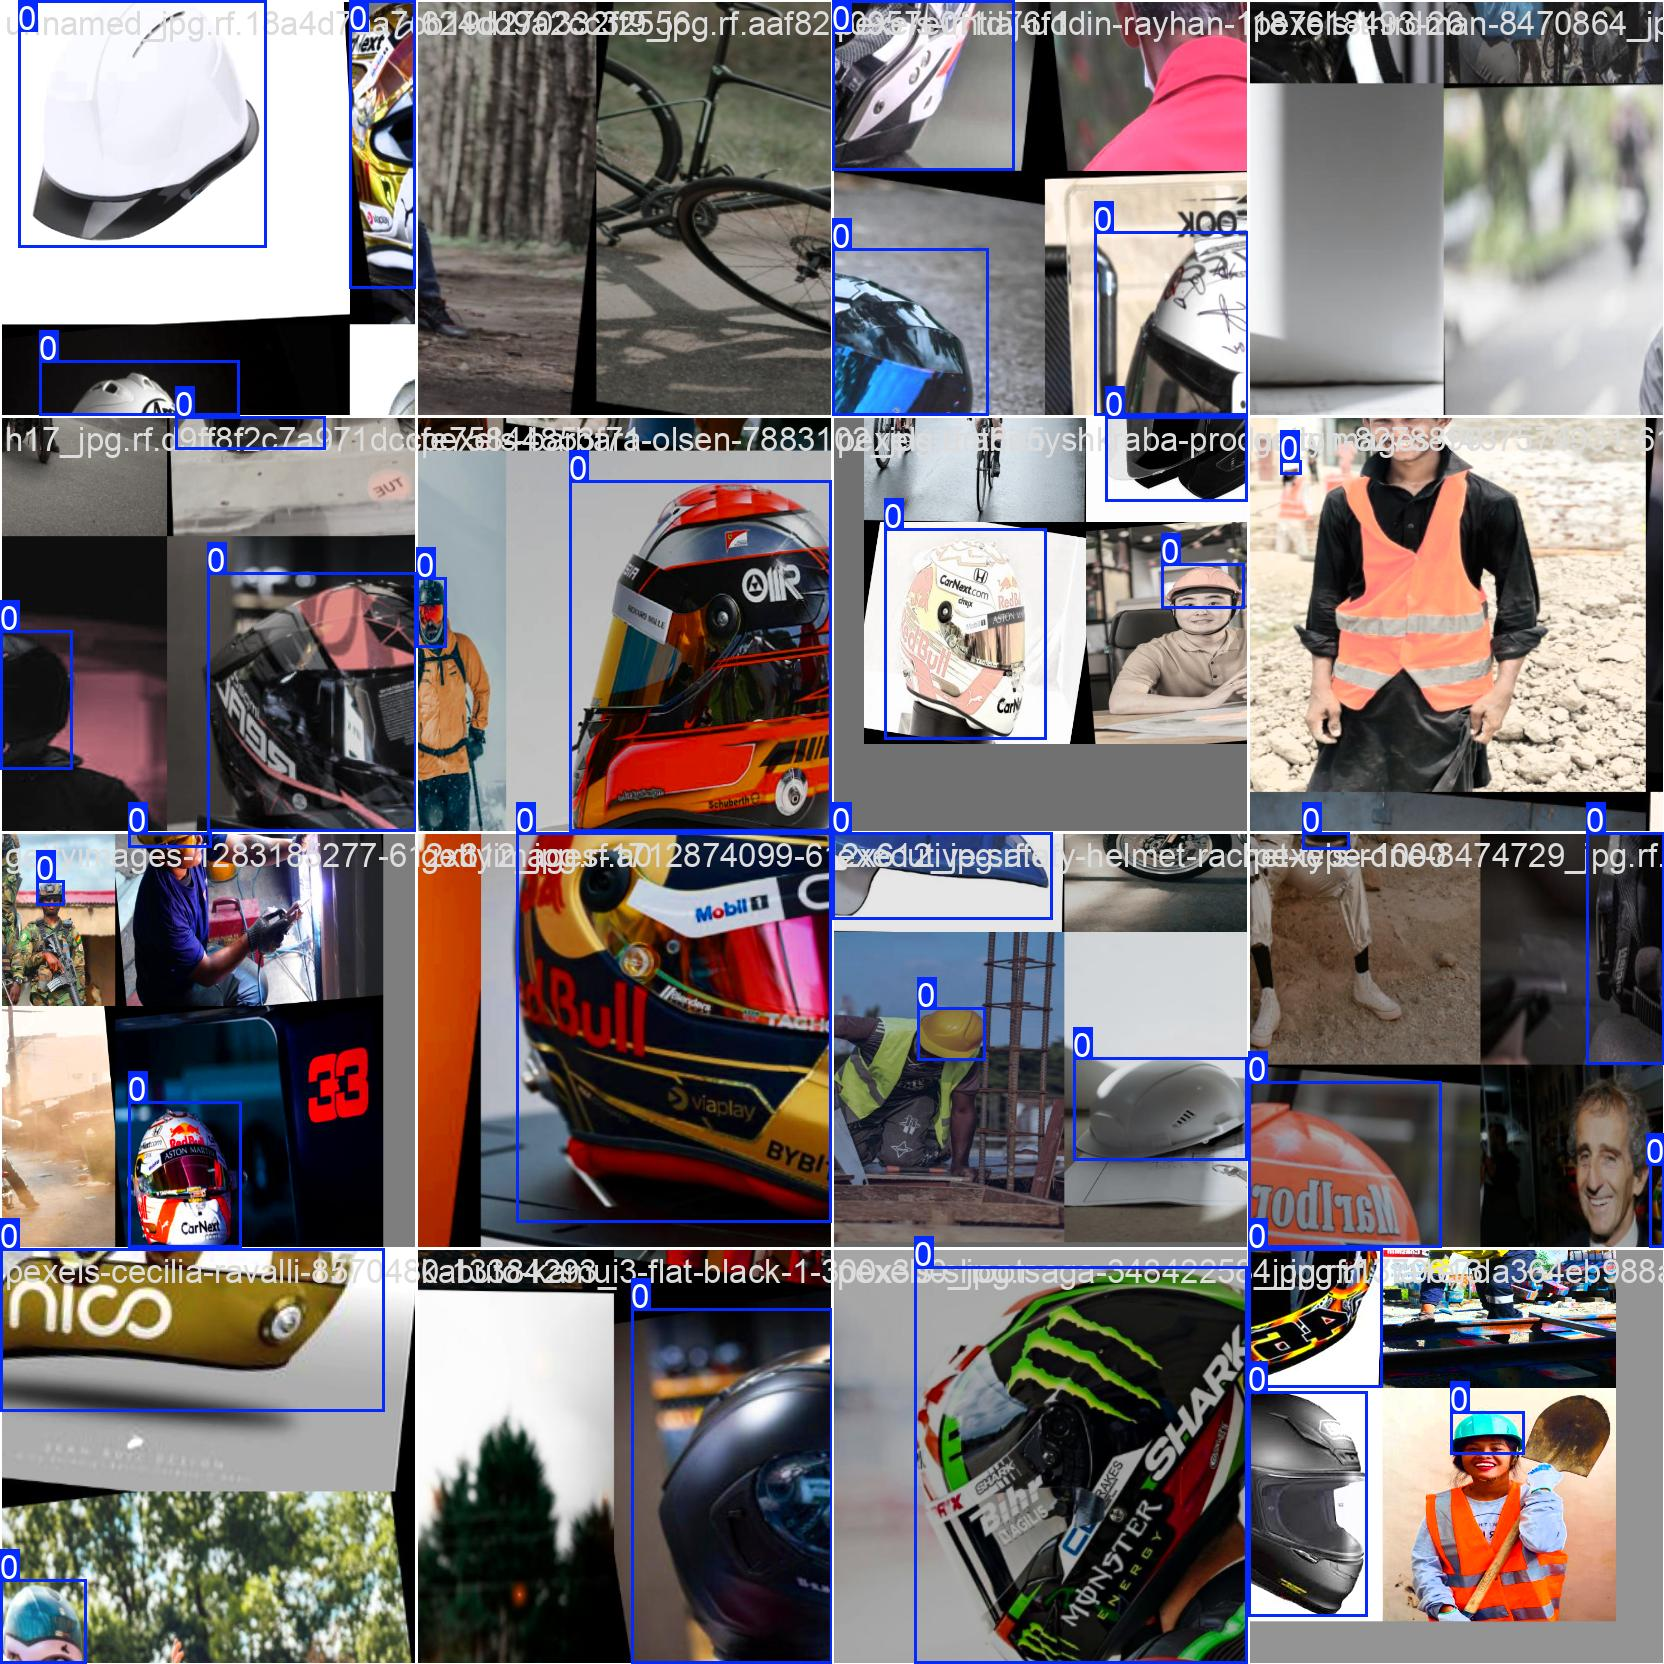

In [ ]:
print("GROUND TRUTH TRAINING DATA:")
Image(filename='/content/yolov5/runs/train/yolov5s_results/train_batch0.jpg', width=900)

In [ ]:
%ls runs/

train/


In [ ]:
%ls runs/train/yolov5s_results/weights

best.pt  last.pt


In [ ]:
%cd /content/yolov5/
!python detect.py --weights runs/train/yolov5s_results/weights/best.pt --img 416 --conf 0.5 --source ../personhelmetvideo.mp4

/content/yolov5
detect: weights=['runs/train/yolov5s_results/weights/best.pt'], source=../personhelmetvideo.mp4, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-555-g4add2aff Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
custom_YOLOv5s summary: 68 layers, 7,012,822 parameters, 0 gradients, 15.8 GFLOPs
video 1/1 (1/329) /content/personhelmetvideo.mp4: 224x416 2 Helmets, 40.6ms
video 1/1 (2/329) /content/personhelmetvideo.mp4: 224x416 1 Helmet, 10.7ms
video 1/1 (3/329) /content/personhelmetvideo.mp4: 224x416 2 Helmets, 7.7ms
video 1/1 (4/329) /content/personhelmetvideo.mp4: 224x416 2 He